In [58]:
#installing yfinace library
!pip install yfinance


In [59]:
#import library
import yfinance as yf

In [60]:
#import amazon stock from 1st january 2020 to 30th april 2026
ticker = 'AMZN'
data = yf.download(ticker, start='2020-01-01', end='2026-04-30')

/tmp/ipykernel_2304/1636454456.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2020-01-01', end='2026-04-30')
[*********************100%***********************]  1 of 1 completed


In [61]:
# print head of data set
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2020-01-02,94.900497,94.900497,93.207497,93.750000,80580000
2020-01-03,93.748497,94.309998,93.224998,93.224998,75288000
2020-01-06,95.143997,95.184502,93.000000,93.000000,81236000
2020-01-07,95.343002,95.694504,94.601997,95.224998,80898000
2020-01-08,94.598503,95.550003,94.321999,94.902000,70160000


In [62]:
#print all columns names
data.columns.to_list()

[('Close', 'AMZN'),
 ('High', 'AMZN'),
 ('Low', 'AMZN'),
 ('Open', 'AMZN'),
 ('Volume', 'AMZN')]

In [63]:
#use .info to check Dataset Structure & Data Types
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1589 entries, 2020-01-02 to 2026-04-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AMZN)   1589 non-null   float64
 1   (High, AMZN)    1589 non-null   float64
 2   (Low, AMZN)     1589 non-null   float64
 3   (Open, AMZN)    1589 non-null   float64
 4   (Volume, AMZN)  1589 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 74.5 KB


In [64]:
#use .describe for Statistical Summary of dataset
data.describe().round(2)

Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
count,1589.00,1589.00,1589.00,1589.00,1.589000e+03
mean,161.89,163.86,159.84,161.92,6.375746e+07
std,41.87,42.12,41.60,41.92,3.293770e+07
min,81.82,83.48,81.30,82.08,1.142050e+07
25%,128.78,130.76,127.10,129.33,4.195120e+07
50%,162.05,164.02,160.25,162.12,5.539240e+07
75%,187.06,188.94,185.33,187.20,7.528800e+07
max,263.99,265.91,260.34,263.46,3.113460e+08


In [65]:
#checking for null values
data.isnull().sum()

,,0
Price,Ticker,
Close,AMZN,0
High,AMZN,0
Low,AMZN,0
Open,AMZN,0
Volume,AMZN,0


In [66]:
#checking for if any duplicate record found
data.duplicated().sum()

np.int64(0)

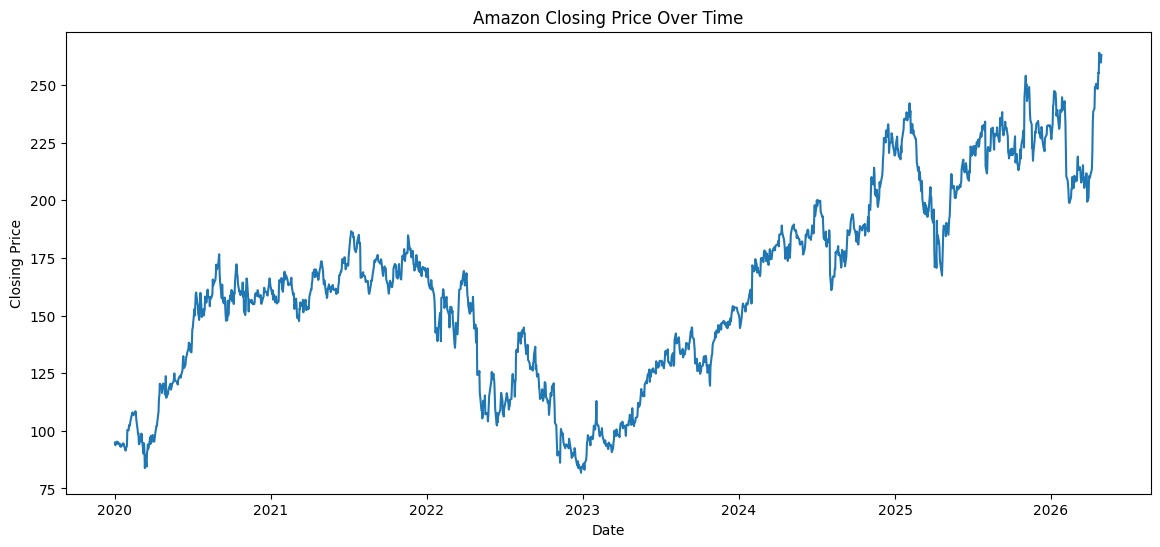

In [67]:
#import libraries for visualisation
import seaborn as sns
import matplotlib.pyplot as plt

#figure size
plt.figure(figsize=(14,6))

sns.lineplot(x=data.index, y=data['Close'].squeeze())

plt.title('Amazon Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

In [68]:
#feature engeneering as we have to predict next day next Close price.
data['Next_Close'] = data['Close'].shift(-1)
data = data.dropna()

In [70]:
data.head()

Price,Close,High,Low,Open,Volume,Next_Close
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,
Date,,,,,,
2020-01-02,94.900497,94.900497,93.207497,93.750000,80580000,93.748497
2020-01-03,93.748497,94.309998,93.224998,93.224998,75288000,95.143997
2020-01-06,95.143997,95.184502,93.000000,93.000000,81236000,95.343002
2020-01-07,95.343002,95.694504,94.601997,95.224998,80898000,94.598503
2020-01-08,94.598503,95.550003,94.321999,94.902000,70160000,95.052498


In [72]:
#prepareing feature and targets
x = data[['Open', 'High', 'Low', 'Volume']]
y = data['Next_Close']

In [74]:
#import sklearn library to
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=False)

In [75]:
#print shape of training and testing data
print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

x_train shape: (1270, 4)
x_test shape: (318, 4)


In [77]:
from sklearn.preprocessing import StandardScaler

In [80]:
#apply feature scaling to x training and test data using std
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [81]:
#training linear regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [83]:
lr_model = LinearRegression()

In [84]:
lr_model.fit(x_train_scaled, y_train)

LinearRegression()

In [85]:
#testing model on unseen data
lr_pred = lr_model.predict(x_test_scaled)

In [86]:
# model evaluation
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

In [88]:
mae = mean_absolute_error(y_test, lr_pred)
mse = mean_squared_error(y_test, lr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 2.5382843840874347
Mean Squared Error: 13.432116817480862
Root Mean Squared Error: 3.664985241100005
R-squared: 0.9921184984798112


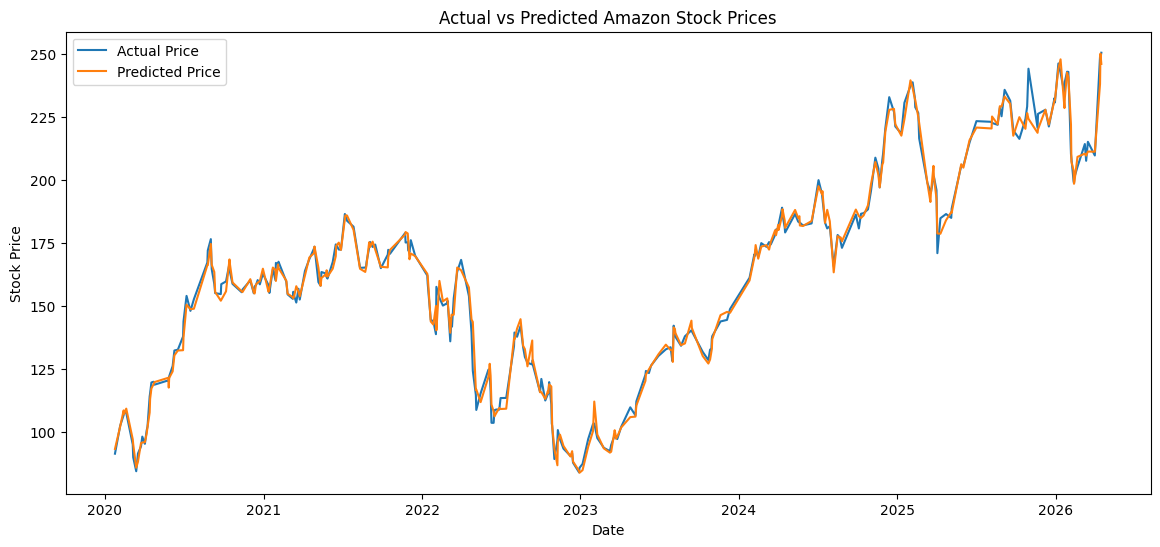

In [89]:
# create figure size
plt.figure(figsize=(14,6))

# actual prices
sns.lineplot(x=y_test.index, y=y_test.squeeze(), label='Actual Price')

# predicted prices
sns.lineplot(x=y_test.index, y=lr_pred, label='Predicted Price')

# graph title and labels
plt.title('Actual vs Predicted Amazon Stock Prices')

plt.xlabel('Date')

plt.ylabel('Stock Price')

plt.legend()

plt.show()